Yield Curve Fit - Nelson Siegel and Cubic Spline



In [ ]:
import pandas as pd
import numpy as np
from fredapi import Fred
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.nelson_siegel import fit_ns, ns_yields, ns_forward, ns_loadings
from src.cubic_spline import cs_interp_fit, cs_smooth_fit,cs_forward
from fred_data import load_fred_data
from config import VALUATION_DATE
import warnings
warnings.filterwarnings('ignore')

In [2]:
plt.rcParams.update({
    'figure.dpi': 90,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.family': 'serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
BLUE   = '#1f4e79'
ORANGE = '#c55a11'
GREEN  = '#375623'
GREY   = '#595959'

In [3]:
yields = load_fred_data()

In [ ]:
bond_yields = yields.loc[VALUATION_DATE]

In [6]:
def plot_yield_curve(date):
    maturities = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
    
    fig, ax=plt.subplots(figsize=(6,4))
    ax.plot(maturities, yields.loc[date], marker='D', label='Yield Curve at ' + date)
    
    ax.set_yticklabels(['{:.2f}%'.format(y) for y in ax.get_yticks()])
    ax.set_xticks(range(len(maturities)))
    ax.set_xticklabels(maturities)

    ax.set_xlabel('Maturity')
    ax.set_ylabel('Yield')
    ax.set_title('Treasury Yield Curve')

    ax.legend(loc = [0.69, 0.04])

    plt.grid(True)
    plt.show()

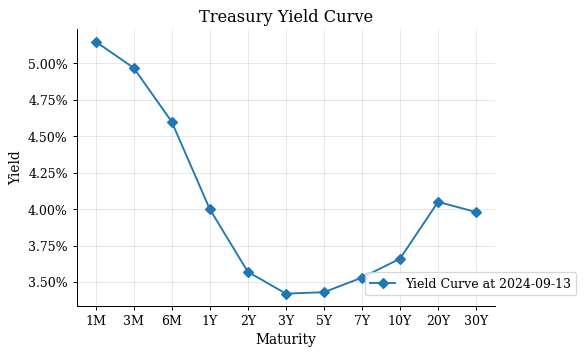

In [ ]:
plot_yield_curve(VALUATION_DATE)

In [8]:
NS = fit_ns(maturities, bond_yields)

print("Nelson-Siegel Fitted Parameters")
print("="*42)
print(f"  β₀  (Level)     = {NS['b0']:>8.4f}%  ← long-run yield")
print(f"  β₁  (Slope)     = {NS['b1']:>8.4f}%  ← {'inverted (β₁>0)' if NS['b1']>0 else 'normal (β₁<0)'}")
print(f"  β₂  (Curvature) = {NS['b2']:>8.4f}%")
print(f"  λ   (Decay)     = {NS['lam']:>8.4f}   ← hump at τ* = {1/NS['lam']:.2f} yr")
print(f"\n  RMSE            = {NS['rmse']*100:>8.4f} bp")
print(f"  MAE             = {NS['mae']*100:>8.4f} bp")

Nelson-Siegel Fitted Parameters
  β₀  (Level)     =   3.6563%  ← long-run yield
  β₁  (Slope)     =   2.0112%  ← inverted (β₁>0)
  β₂  (Curvature) =  -1.4653%
  λ   (Decay)     =   2.5997   ← hump at τ* = 0.38 yr

  RMSE            =  23.1530 bp
  MAE             =  20.4751 bp


In [9]:
cs_interp = cs_interp_fit(maturities, bond_yields)

cs_smooth = cs_smooth_fit(maturities, bond_yields, k=3, s=0.08)
  
for name, pred_fn in [('Interpolating', lambda t : cs_interp(t)), ('Smoothing', lambda t : cs_smooth(t))]:
  residual = bond_yields - pred_fn(maturities)
  rmse = np.sqrt(np.mean(residual**2))
  mae = np.mean(np.abs(residual))
  print(f"{name:20s}  RMSE = {rmse*100:7.4f} bp   MAE = {mae*100:7.4f} bp")

Interpolating         RMSE =  0.0000 bp   MAE =  0.0000 bp
Smoothing             RMSE =  8.5287 bp   MAE =  7.7684 bp


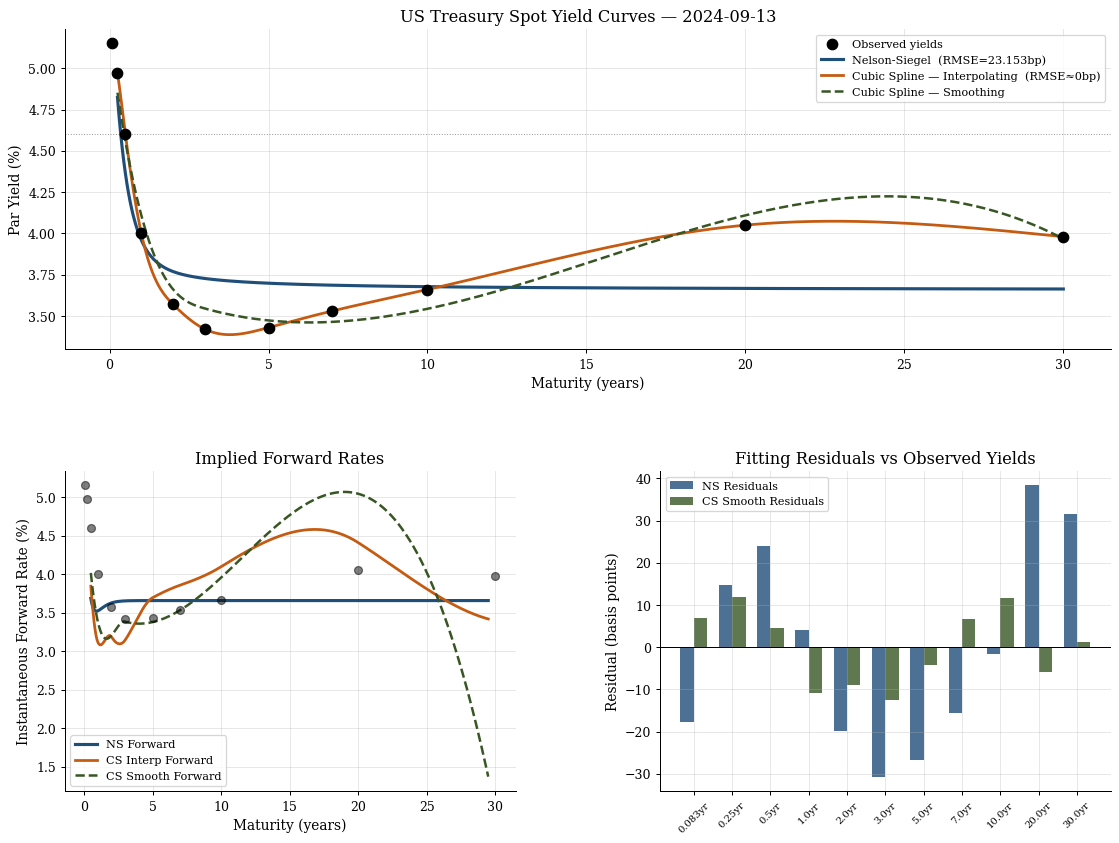

In [14]:
tau_fine = np.linspace(0.25, 30, 600)
fwd_tau = np.linspace(0.5, 29.5, 500)

fig = plt.figure(figsize=(15,11))
gs = gridspec.GridSpec(2,2, hspace=0.38, wspace=0.32)

ax1=fig.add_subplot(gs[0,:])
ax1.scatter(maturities, bond_yields, color='black', zorder=6, s=70, label='Observed yields')
ax1.plot(tau_fine, ns_yields(tau_fine, **{k:NS[k] for k in ['b0','b1','b2','lam']}), color=BLUE,   lw=2.5, label=f"Nelson-Siegel  (RMSE={NS['rmse']*100:.3f}bp)")
ax1.plot(tau_fine, cs_interp(tau_fine), color=ORANGE, lw=2.2, label=f'Cubic Spline — Interpolating  (RMSE≈0bp)')
ax1.plot(tau_fine, cs_smooth(tau_fine), color=GREEN,  lw=2.0, ls='--', label=f'Cubic Spline — Smoothing')
ax1.axhline(bond_yields.iloc[2], color=GREY, lw=0.8, ls=':', alpha=0.6)
ax1.set_xlabel('Maturity (years)')
ax1.set_ylabel('Par Yield (%)')
ax1.set_title(f'US Treasury Spot Yield Curves — {observation_date}')
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(fwd_tau, ns_forward(fwd_tau, NS['b0'],NS['b1'],NS['b2'],NS['lam']),
         color=BLUE,   lw=2.5, label='NS Forward')
ax2.plot(fwd_tau, cs_forward(cs_interp, fwd_tau, 'cubic'),
         color=ORANGE, lw=2.2, label='CS Interp Forward')
ax2.plot(fwd_tau, cs_forward(cs_smooth, fwd_tau, 'smooth'),
         color=GREEN,  lw=2.0, ls='--', label='CS Smooth Forward')
ax2.scatter(maturities, bond_yields, color='black', s=40, zorder=5, alpha=0.5)
ax2.set_xlabel('Maturity (years)')
ax2.set_ylabel('Instantaneous Forward Rate (%)')
ax2.set_title('Implied Forward Rates')
ax2.legend(fontsize=9)

ax3 = fig.add_subplot(gs[1, 1])
ns_resid = (bond_yields - ns_yields(maturities, NS['b0'],NS['b1'],NS['b2'],NS['lam'])) * 100
cs_resid = (bond_yields - cs_smooth(maturities)) * 100
x = np.arange(len(maturities))
w = 0.35
ax3.bar(x - w/2, ns_resid, width=w, color=BLUE,   alpha=0.8, label='NS Residuals')
ax3.bar(x + w/2, cs_resid, width=w, color=GREEN,  alpha=0.8, label='CS Smooth Residuals')
ax3.axhline(0, color='black', lw=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels([f'{m}yr' for m in maturities], rotation=45, fontsize=8)
ax3.set_ylabel('Residual (basis points)')
ax3.set_title('Fitting Residuals vs Observed Yields')
ax3.legend(fontsize=9)
plt.show()